# t-SNE (t-Distributed Stochastic Neighbor Embedding)

# DATA

In [1]:
import numpy as np

X = np.array([
    [1, 2],
    [2, 1],
    [2, 3],
    [8, 8],
    [9, 8],
    [8, 9]
], dtype=float)

print(len(X))

print(X)

6
[[1. 2.]
 [2. 1.]
 [2. 3.]
 [8. 8.]
 [9. 8.]
 [8. 9.]]


# Pairwise Distance Matrix Using Euclidean distance

In [2]:
def dis_matrix(X):

    n = len(X)
    # empty matrix
    distance = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            distance[i][j] = np.sqrt(np.sum((X[i] - X[j]) ** 2))

    # print(distance)

    return distance


distance = dis_matrix(X)

distance

array([[ 0.        ,  1.41421356,  1.41421356,  9.21954446, 10.        ,
         9.89949494],
       [ 1.41421356,  0.        ,  2.        ,  9.21954446,  9.89949494,
        10.        ],
       [ 1.41421356,  2.        ,  0.        ,  7.81024968,  8.60232527,
         8.48528137],
       [ 9.21954446,  9.21954446,  7.81024968,  0.        ,  1.        ,
         1.        ],
       [10.        ,  9.89949494,  8.60232527,  1.        ,  0.        ,
         1.41421356],
       [ 9.89949494, 10.        ,  8.48528137,  1.        ,  1.41421356,
         0.        ]])

# Entropy

In [3]:
def compute_entropy(p):

    # entropy = -np.sum(p * np.log2(p))

    epsilon = 1e-15

    p = np.clip(p, epsilon, 1 - epsilon)

    entropy = - np.sum(p * np.log2(p))

    return entropy

# perplexity

In [4]:
def compute_perplexity(H):
    return 2 ** H


# Find Sigma using binary search

In [5]:
def find_best_sigma(distance_row, target_perplexity = 30, tolerance = 1e-5, max_iter = 50):

    sigma = 1.0

    sigma_min = 0.0
    sigma_max = np.inf

    for _ in range(max_iter):

        # Step 1 Gaussian Similarity 
        similarity = np.exp(-(distance_row ** 2) / (2 * sigma ** 2))

        similarity[distance_row == 0] = 0

        # print("Similarity : ", similarity)

        # Step 2 Conditional Probability  
        probability = similarity / np.sum(similarity)

        # print("probability : ", probability)
        # print("Total probabilit : ", np.sum(probability))

        # step 3 Entropy                          
        entropy = compute_entropy(probability)    

        # print("entropy : ", entropy)

        # step 4 perplexity
        current_perplexity = compute_perplexity(entropy)

        if abs(current_perplexity - target_perplexity) < tolerance:
            break

        elif current_perplexity < target_perplexity:
            sigma_min = sigma

            if sigma_max == np.inf:
                sigma *= 2

            else:
                sigma = (sigma + sigma_max)/2

        else:
            sigma_max = sigma

            sigma = (sigma + sigma_min) / 2

    return sigma


In [6]:
def conditional_probability(distance, target_perplexity = 30):

    n = len(distance)

    p = np.zeros((n, n))

    for i in range(n):

        sigma = find_best_sigma(distance[i], target_perplexity=target_perplexity)

        # print(f"Row {i} Sigma {sigma}")

        # Gaussian Similarity
        similarity = np.exp((-distance[i] ** 2) / (2 * sigma ** 2))

        similarity[i] = 0

        # Normalize
        p[i] = similarity / np.sum(similarity)

    return p

# Joint Probability Matrix

In [7]:
def joint_probability(p_conditional):

    n = len(p_conditional)

    p_joint = (p_conditional + p_conditional.T) / (2 * n)

    return p_joint

In [8]:
p_conditional = conditional_probability(distance, target_perplexity = 2)

P = joint_probability(p_conditional)

print(P)

print(np.sum(P))

[[0.00000000e+00 8.70797483e-02 8.81579973e-02 6.34536747e-20
  6.68748502e-07 6.83122948e-07]
 [8.70797483e-02 0.00000000e+00 7.46551945e-02 2.44964225e-05
  8.37438778e-06 6.83129075e-06]
 [8.81579973e-02 7.46551945e-02 0.00000000e+00 4.60360590e-05
  2.23466520e-05 2.59678690e-05]
 [6.34536747e-20 2.44964225e-05 4.60360590e-05 0.00000000e+00
  8.56582104e-02 8.57014772e-02]
 [6.68748502e-07 8.37438778e-06 2.23466520e-05 8.56582104e-02
  0.00000000e+00 7.86119678e-02]
 [6.83122948e-07 6.83129075e-06 2.59678690e-05 8.57014772e-02
  7.86119678e-02 0.00000000e+00]]
0.9999999999999999


In [9]:
print(np.allclose(P, P.T))

True


# Random Position for points

In [10]:
def initialize_embedding(n_samples,
                         n_components=2,
                         random_state=42):

    np.random.seed(random_state)

    Y = np.random.randn(
        n_samples,
        n_components
    ) * 0.0001

    return Y

Y = initialize_embedding(6)

print(Y)

[[ 4.96714153e-05 -1.38264301e-05]
 [ 6.47688538e-05  1.52302986e-04]
 [-2.34153375e-05 -2.34136957e-05]
 [ 1.57921282e-04  7.67434729e-05]
 [-4.69474386e-05  5.42560044e-05]
 [-4.63417693e-05 -4.65729754e-05]]


In [11]:
distance_low = dis_matrix(Y)

print(distance_low)

[[0.00000000e+00 1.66814014e-04 7.37128828e-05 1.41141563e-04
  1.18196535e-04 1.01443915e-04]
 [1.66814014e-04 0.00000000e+00 1.96603163e-04 1.19944215e-04
  1.48639633e-04 2.27809610e-04]
 [7.37128828e-05 1.96603163e-04 0.00000000e+00 2.07157978e-04
  8.11562819e-05 3.25879350e-05]
 [1.41141563e-04 1.19944215e-04 2.07157978e-04 0.00000000e+00
  2.06099196e-04 2.38600797e-04]
 [1.18196535e-04 1.48639633e-04 8.11562819e-05 2.06099196e-04
  0.00000000e+00 1.00830799e-04]
 [1.01443915e-04 2.27809610e-04 3.25879350e-05 2.38600797e-04
  1.00830799e-04 0.00000000e+00]]


In [12]:
def student_t_probability(distance_low):

    n = len(distance_low)

    # Store the Student's t similarity
    similarity = np.zeros((n, n))

    for i in range(n):
        for j in range(n):

            if i != j:

                # Student's t-distribution
                similarity[i][j] = 1 / (
                    1 + distance_low[i][j] ** 2
                )

    # Normalize all similarities
    q = similarity / np.sum(similarity)

    return q

Q = student_t_probability(distance_low)

In [13]:
def kl_divergence(P, Q):

    # Avoid log(0)
    epsilon = 1e-12

    P_safe = P + epsilon
    Q_safe = Q + epsilon

    kl = np.sum(
        P_safe * np.log(P_safe / Q_safe)
    )

    return kl

In [14]:
loss = kl_divergence(P, Q)

print("KL Divergence : ", loss)

KL Divergence :  0.9156100813609047


In [15]:
def compute_gradient(P, Q, Y):

    n = len(Y)

    # Gradient for every point
    gradient = np.zeros_like(Y)

    for i in range(n):

        for j in range(n):

            if i != j:

                # Difference between desired probability
                # and current probability
                probability_difference = P[i][j] - Q[i][j]

                # Direction from point j to point i
                direction = Y[i] - Y[j]

                # Squared distance between points
                distance_squared = np.sum(
                    (Y[i] - Y[j]) ** 2
                )

                # Student-t distance factor
                distance_factor = 1 / (
                    1 + distance_squared
                )

                # Add this pair's contribution
                gradient[i] += (
                    4
                    * probability_difference
                    * direction
                    * distance_factor
                )

    return gradient


# Compute Gradient

In [16]:
gradient = compute_gradient(P, Q, Y)

print(gradient)

[[ 1.53165796e-06 -1.68256206e-05]
 [ 5.29192397e-07  1.51109991e-05]
 [-1.26487296e-05 -1.05468709e-05]
 [ 3.46770932e-05  1.51933951e-05]
 [-1.20790880e-05  7.19813072e-06]
 [-1.20101259e-05 -1.01300334e-05]]


# Gradient descent

In [17]:
learning_rate = 200

Y = Y - learning_rate * gradient

Y

array([[-2.56660177e-04,  3.35129769e-03],
       [-4.10696257e-05, -2.86989683e-03],
       [ 2.50633059e-03,  2.08596048e-03],
       [-6.77749735e-03, -2.96193554e-03],
       [ 2.36887016e-03, -1.38537014e-03],
       [ 2.35568341e-03,  1.97943370e-03]])

In [18]:
# 1. Calculate new distances
distance_low = dis_matrix(Y)

# 2. Calculate new Q
Q = student_t_probability(distance_low)

# 3. Calculate new KL loss
loss_after = kl_divergence(P, Q)

print("KL before :", loss)
print("KL after  :", loss_after)

KL before : 0.9156100813609047
KL after  : 0.9156173775020454


In [19]:
Y_old = Y.copy()

for learning_rate in [1, 5, 10, 20, 50, 100, 200]:

    Y_test = Y_old - learning_rate * gradient

    distance_test = dis_matrix(Y_test)

    Q_test = student_t_probability(distance_test)

    loss_test = kl_divergence(P, Q_test)

    print(
        "LR:", learning_rate,
        "KL:", loss_test
    )

LR: 1 KL: 0.9156174533256516
LR: 5 KL: 0.9156177605352953
LR: 10 KL: 0.9156181533566627
LR: 20 KL: 0.9156189683642555
LR: 50 KL: 0.9156216483155392
LR: 100 KL: 0.9156268980671992
LR: 200 KL: 0.9156403350807949


In [20]:
def tsne_optimize(P, Y, learning_rate=10, iterations=1000):

    for iteration in range(iterations):

        # 1. Calculate distances in 2D
        distance_low = dis_matrix(Y)

        # 2. Calculate Q
        Q = student_t_probability(distance_low)

        # 3. Calculate KL divergence
        loss = kl_divergence(P, Q)

        # 4. Calculate gradient
        gradient = compute_gradient(P, Q, Y)

        # 5. Update Y
        Y = Y - learning_rate * gradient

        # Print progress
        if iteration % 100 == 0:
            print(
                f"Iteration: {iteration}, "
                f"KL Loss: {loss}"
            )

    return Y

In [21]:
Y = initialize_embedding(len(P))

Y_final = tsne_optimize(
    P,
    Y,
    learning_rate=10,
    iterations=1000
)

Iteration: 0, KL Loss: 0.9156100813609047
Iteration: 100, KL Loss: 0.017081275413280375
Iteration: 200, KL Loss: 0.011712109840268676
Iteration: 300, KL Loss: 0.009388170754283153
Iteration: 400, KL Loss: 0.008020357932155105
Iteration: 500, KL Loss: 0.007095229923408584
Iteration: 600, KL Loss: 0.006417092450736879
Iteration: 700, KL Loss: 0.005893100900156001
Iteration: 800, KL Loss: 0.005472612049266872
Iteration: 900, KL Loss: 0.005118157623961576


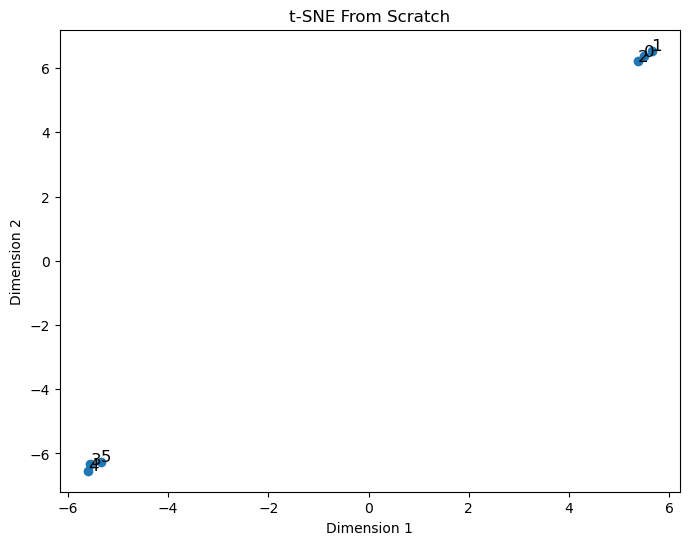

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    Y_final[:, 0],
    Y_final[:, 1]
)

for i in range(len(Y_final)):
    plt.text(
        Y_final[i, 0],
        Y_final[i, 1],
        str(i),
        fontsize=12
    )

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("t-SNE From Scratch")

plt.show()

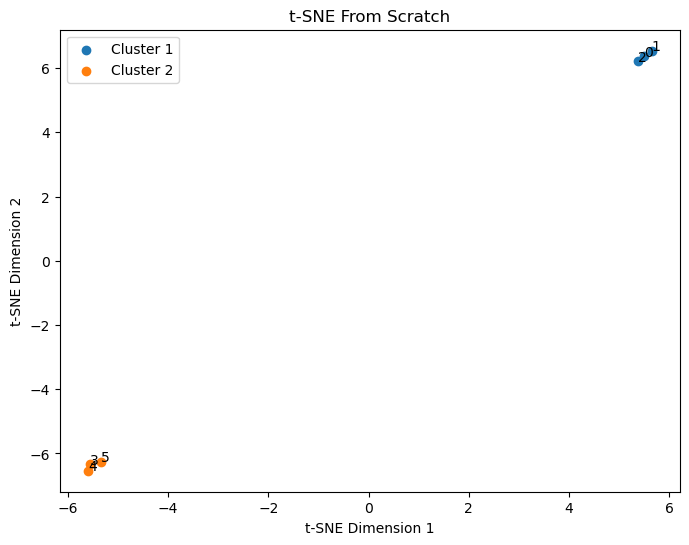

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(
    Y_final[:3, 0],
    Y_final[:3, 1],
    label="Cluster 1"
)

plt.scatter(
    Y_final[3:, 0],
    Y_final[3:, 1],
    label="Cluster 2"
)

for i in range(len(Y_final)):
    plt.text(
        Y_final[i, 0],
        Y_final[i, 1],
        str(i)
    )

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE From Scratch")
plt.legend()

plt.show()